In [1]:
import numpy as np

In [ ]:
income = np.loadtxt(
    "https://raw.githubusercontent.com/nickeubank/practicaldatascience/master/Example_Data/us_household_incomes.txt"
)

In [3]:
income[:5]

array([ 53308., 102050., 192994.,  46932.,  43803.])

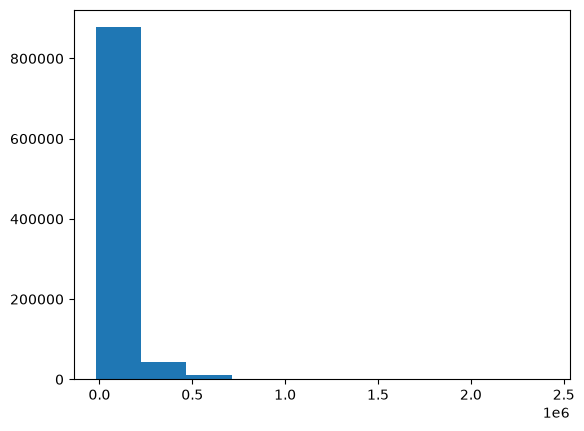

In [4]:
from matplotlib import pyplot as plt

plt.hist(income)
plt.show()

The income distribution does not look uniform or normal. It is strongly right-skewed, with most households concentrated at lower income levels and a smaller number of households having very high incomes. This suggests that income is not equally distributed among households.

In [5]:
income_under_500k = income[income < 500000]

(array([262190., 338722., 173615.,  76580.,  33854.,  16134.,   8329.,
          5401.,   4556.,   4038.]),
 array([-16942.,  34752.,  86446., 138140., 189834., 241528., 293222.,
        344916., 396610., 448304., 499998.]),
 <BarContainer object of 10 artists>)

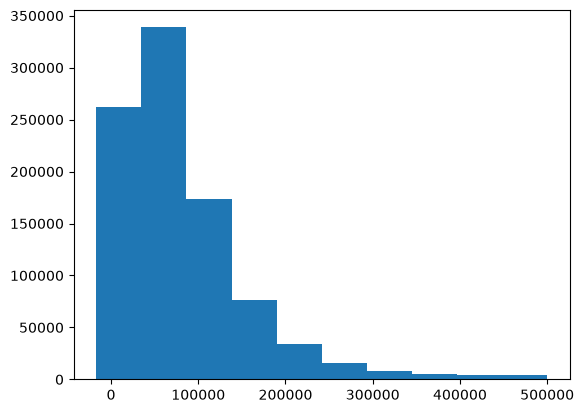

In [6]:
plt.hist(income_under_500k)

Even after excluding households with incomes above $500,000.00, the distribution is still right skewed. This indicates that the skewness in the U.S income distribution is not caused only by extremely high earners. There is still a concentration of households at lower levels and fewer households at higher incomes levels within the remaining range therefore the right-skewness is evident across the income distribution, not just among high income earners.

In [13]:
ex4_share_below_poverty = np.mean(income < 20000)

In [12]:
np.mean(income < 20000)

np.float64(0.14711442173300704)

In [66]:

def gini(x):
     x = np.asarray(x, dtype=float).ravel()
     if x.size == 0:
        return 0.0
     if np.any(x < 0):
        x = x - np.min(x)
     x = np.sort(x)
     n = x.size
     index = np.arange(1, n + 1)
     return np.sum((2 * index - n - 1) * x) / (n * np.sum(x))
  

In [47]:
ex4_gini = gini(income)
ex4_gini

np.float64(0.40364442793732347)

The U.S Gini index is approximately 0.404 or 40.4 while Botswana's Gini index is above 50 in the tears shown. Since a higher Gini coefficient indicates greater income inequality, the botswana valuses shown represent greater income inequality than the U.S value calculated from our data. This suggests that income is distributed more unevenly in Botswana than in the U.S.

In [67]:
income_policy_a = income.copy()
income_policy_a[income_policy_a < 40000] += 5000

In [68]:
ex6_gini_policy_a = gini(income_policy_a)
ex6_gini_policy_a

np.float64(0.4062898737409396)

In [69]:
income_policy_b = income.copy()
income_policy_b[income_policy_b < 30000] += 7000

In [70]:
ex6_gini_policy_b = gini(income_policy_b)
ex6_gini_policy_b

np.float64(0.4126723978651541)

In [71]:
results = {}

In [72]:
results["ex6_gini_policy_a"] = ex6_gini_policy_a
results["ex6_gini_policy_b"] = ex6_gini_policy_b

In [73]:
results["ex6_gini_which_reduced_more"] = (
    "Policy A" if ex6_gini_policy_a < ex6_gini_policy_b else "Policy B"
)

In [74]:
income_policy_c = income.copy()
income_policy_c[income_policy_c < 250000] *= 0.95

In [75]:
ex7_gini_policy_c = gini(income_policy_c)
ex7_gini_policy_c

np.float64(0.4091558297918161)

In [76]:
results["ex7_gini_policy_c"] = ex7_gini_policy_c

In [77]:
ex8_revenue_raised = np.sum(income[income > 250000] * 0.05)
results["ex8_revenue_raised"] = ex8_revenue_raised
ex8_revenue_raised

np.float64(929623340.8500001)

In [78]:
ex9_transfers = results["ex8_revenue_raised"] / np.sum(income < 30000)
results["ex9_transfers"] = ex9_transfers
ex9_transfers

np.float64(4208.230382379837)

In [80]:
income_policy_d = income.copy()
income_policy_d[income_policy_d > 250000] *= 0.95
income_policy_d[income_policy_d < 30000] += results["ex9_transfers"]

ex10_gini_policy_d = gini(income_policy_d)
results["ex10_gini_policy_d"] = ex10_gini_policy_d
ex10_gini_policy_d

np.float64(0.40348162248564)

In [81]:
income_policy_e = income.copy()
income_policy_e[income_policy_e > 250000] *= 0.95
income_policy_e[income_policy_e < 40000] += results["ex8_revenue_raised"] / np.sum(
    income < 40000
)

ex11_gini_policy_e = gini(income_policy_e)
results["ex11_gini_policy_e"] = ex11_gini_policy_e
ex11_gini_policy_e

np.float64(0.39981705623821356)

In [82]:
results["ex12_policy_recommendation"] = (
    "Policy D" if ex10_gini_policy_d < ex11_gini_policy_e else "Policy E"
)
results["ex12_policy_recommendation"]

'Policy E'

In [83]:
results["ex4_share_below_poverty"] = ex4_share_below_poverty
results["ex4_gini"] = ex4_gini
results

{'ex6_gini_policy_a': np.float64(0.4062898737409396),
 'ex6_gini_policy_b': np.float64(0.4126723978651541),
 'ex6_gini_which_reduced_more': 'Policy A',
 'ex7_gini_policy_c': np.float64(0.4091558297918161),
 'ex8_revenue_raised': np.float64(929623340.8500001),
 'ex9_transfers': np.float64(4208.230382379837),
 'ex10_gini_policy_d': np.float64(0.40348162248564),
 'ex11_gini_policy_e': np.float64(0.39981705623821356),
 'ex12_policy_recommendation': 'Policy E',
 'ex4_share_below_poverty': np.float64(0.14711442173300704),
 'ex4_gini': np.float64(0.40364442793732347)}

In [85]:
assert set(results.keys()) == {
    "ex4_share_below_poverty",
    "ex4_gini",
    "ex6_gini_policy_a",
    "ex6_gini_policy_b",
    "ex6_gini_which_reduced_more",
    "ex7_gini_policy_c",
    "ex8_revenue_raised",
    "ex9_transfers",
    "ex10_gini_policy_d",
    "ex11_gini_policy_e",
    "ex12_policy_recommendation",
}